In [13]:
"""
DEEPFAKE DETECTION SYSTEM - JUPYTER NOTEBOOK VERSION
===================================================
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Fuzzy Logic
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Image Processing
from PIL import Image

# For Jupyter display
from IPython.display import display, Image as IPImage

print("="*70)
print("✓ All libraries imported successfully!")
print("="*70)

# Check TensorFlow version
print(f"\nTensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


✓ All libraries imported successfully!

TensorFlow version: 2.15.0
GPU available: False


In [17]:
"""
STEP 2: Extract dataset and configure model parameters
"""

import zipfile
from pathlib import Path

print("="*70)
print("STEP 2: EXTRACTING DATASET & CONFIGURATION")
print("="*70)

# ============================================================================
# PART A: EXTRACT DATASET
# ============================================================================

# Define paths
BASE_DIR = Path.cwd()  # Current working directory
ZIP_FILE = BASE_DIR / 'kabir.zip'  # Your zip file
EXTRACT_DIR = BASE_DIR  # Extract here

print("\n[A] EXTRACTING DATASET")
print("-" * 70)

# Check if zip file exists
if ZIP_FILE.exists():
    print(f"✓ Found: {ZIP_FILE}")
    print(f"  Size: {ZIP_FILE.stat().st_size / (1024*1024):.2f} MB")
    
    # Check if already extracted
    DATASET_DIR = BASE_DIR / 'kabir'
    if DATASET_DIR.exists():
        print(f"\n✓ Dataset already extracted at: {DATASET_DIR}")
    else:
        print(f"\n⏳ Extracting {ZIP_FILE.name}...")
        with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print(f"✓ Extraction complete!")
        print(f"✓ Dataset extracted to: {DATASET_DIR}")
else:
    print(f"❌ ZIP file not found at: {ZIP_FILE}")
    print("\nPlease ensure 'kabir.zip' is in the same folder as this notebook")
    print(f"Current directory: {BASE_DIR}")
    
    # Show what files are in current directory
    print("\nFiles in current directory:")
    for item in BASE_DIR.iterdir():
        if item.is_file():
            print(f"  - {item.name}")

# ============================================================================
# PART B: VERIFY DATASET STRUCTURE
# ============================================================================

print("\n[B] VERIFYING DATASET STRUCTURE")
print("-" * 70)

DATASET_DIR = BASE_DIR / 'kabir'

if DATASET_DIR.exists():
    print(f"✓ Dataset folder found: {DATASET_DIR}\n")
    
    # Check folder structure
    total_images = 0
    dataset_valid = True
    
    for split in ['train', 'val', 'test']:
        split_path = DATASET_DIR / split
        if split_path.exists():
            print(f"{split.upper()}:")
            for cls in ['real', 'fake']:
                cls_path = split_path / cls
                if cls_path.exists():
                    # Count images
                    images = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.png')) + list(cls_path.glob('*.jpeg'))
                    count = len(images)
                    print(f"  ✓ {cls:5}: {count:4} images")
                    total_images += count
                else:
                    print(f"  ❌ {cls:5}: NOT FOUND")
                    dataset_valid = False
        else:
            print(f"{split.upper()}: ❌ NOT FOUND")
            dataset_valid = False
    
    print(f"\n{'='*70}")
    print(f"TOTAL IMAGES: {total_images}")
    print(f"{'='*70}")
    
    if not dataset_valid:
        print("\n⚠ WARNING: Dataset structure is incomplete!")
else:
    print(f"❌ Dataset folder not found at: {DATASET_DIR}")
    dataset_valid = False

# ============================================================================
# PART C: MODEL CONFIGURATION
# ============================================================================

print("\n[C] MODEL CONFIGURATION")
print("-" * 70)

# Model Configuration
IMG_SIZE = 224          # Input image size (224x224 pixels)
BATCH_SIZE = 32         # Number of images processed at once
LEARNING_RATE = 0.001   # How fast the model learns
NUM_CLASSES = 2         # Real vs Fake (binary classification)
EPOCHS = 50             # Maximum training epochs
PATIENCE = 10           # Early stopping patience

# Save configuration as dictionary
CONFIG = {
    'base_dir': BASE_DIR,
    'dataset_dir': DATASET_DIR,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'num_classes': NUM_CLASSES,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'total_images': total_images if dataset_valid else 0
}

print(f"\nDataset Directory:  {DATASET_DIR}")
print(f"Input Image Size:   {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size:         {BATCH_SIZE}")
print(f"Learning Rate:      {LEARNING_RATE}")
print(f"Number of Classes:  {NUM_CLASSES} (Real, Fake)")
print(f"Max Epochs:         {EPOCHS}")
print(f"Early Stop Patience: {PATIENCE}")
print(f"Total Images:       {total_images}")

print("\n" + "="*70)
if dataset_valid:
    print("✓ CONFIGURATION COMPLETE - READY TO PROCEED!")
else:
    print("❌ CONFIGURATION INCOMPLETE - FIX DATASET FIRST!")
print("="*70)

STEP 2: EXTRACTING DATASET & CONFIGURATION

[A] EXTRACTING DATASET
----------------------------------------------------------------------
✓ Found: C:\Users\user\deepfake_project\kabir.zip
  Size: 110.48 MB

✓ Dataset already extracted at: C:\Users\user\deepfake_project\kabir

[B] VERIFYING DATASET STRUCTURE
----------------------------------------------------------------------
✓ Dataset folder found: C:\Users\user\deepfake_project\kabir

TRAIN:
  ✓ real : 4200 images
  ✓ fake : 4200 images
VAL:
  ✓ real :  900 images
  ✓ fake :  900 images
TEST:
  ✓ real :  900 images
  ✓ fake :  900 images

TOTAL IMAGES: 12000

[C] MODEL CONFIGURATION
----------------------------------------------------------------------

Dataset Directory:  C:\Users\user\deepfake_project\kabir
Input Image Size:   224x224
Batch Size:         32
Learning Rate:      0.001
Number of Classes:  2 (Real, Fake)
Max Epochs:         50
Early Stop Patience: 10
Total Images:       12000

✓ CONFIGURATION COMPLETE - READY TO PROCE

In [19]:
from pathlib import Path

class config:
    MODEL_TYPE = "MobileNetV2 Transfer Learning"
    
    IMG_SIZE = IMG_SIZE
    BATCH_SIZE = BATCH_SIZE
    LEARNING_RATE = LEARNING_RATE
    
    EPOCHS = EPOCHS
    PATIENCE = PATIENCE
    
    DATA_DIR = DATASET_DIR
    MODELS_DIR = Path("models")
    RESULTS_DIR = Path("results")

# Create folders
config.MODELS_DIR.mkdir(exist_ok=True)
config.RESULTS_DIR.mkdir(exist_ok=True)

print("✓ config class created successfully")


✓ config class created successfully


In [25]:
class DeepfakeDetector:
    """Deep Learning Model for Deepfake Detection"""
    
    def __init__(self):
        self.model = None
        self.history = None
        self.train_generator = None
        self.val_generator = None
        self.test_generator = None
        
        print(f"[DEEP LEARNING] Initializing {config.MODEL_TYPE}")
        print(f"[DEEP LEARNING] Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
        print(f"[DEEP LEARNING] Batch Size: {config.BATCH_SIZE}\n")
    
    def create_model(self):
        """Create transfer learning model"""
        print("[DEEP LEARNING] Building model...")
        
        # Load base model
        base_model = MobileNetV2(
            input_shape=(config.IMG_SIZE, config.IMG_SIZE, 3),
            include_top=False,
            weights='imagenet'
        )
        
        # Freeze base layers
        base_model.trainable = False
        
        # Build model
        self.model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(2, activation='softmax')
        ])
        
        # Compile
        self.model.compile(
            optimizer=Adam(learning_rate=config.LEARNING_RATE),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print(f"✓ Model created with {self.model.count_params():,} parameters\n")
        return self.model
    
    def prepare_data(self):
        """Prepare data generators"""
        print("[DEEP LEARNING] Preparing data generators...")
        
        # Training augmentation
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.2,
            shear_range=0.2
        )
        
        # Validation/Test (no augmentation)
        val_test_datagen = ImageDataGenerator(rescale=1./255)
        
        # Create generators
        self.train_generator = train_datagen.flow_from_directory(
            str(config.DATA_DIR / 'train'),
            target_size=(config.IMG_SIZE, config.IMG_SIZE),
            batch_size=config.BATCH_SIZE,
            class_mode='categorical',
            shuffle=True
        )
        
        self.val_generator = val_test_datagen.flow_from_directory(
            str(config.DATA_DIR / 'val'),
            target_size=(config.IMG_SIZE, config.IMG_SIZE),
            batch_size=config.BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )
        
        self.test_generator = val_test_datagen.flow_from_directory(
            str(config.DATA_DIR / 'test'),
            target_size=(config.IMG_SIZE, config.IMG_SIZE),
            batch_size=config.BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )
        
        print(f"✓ Training: {self.train_generator.samples} images")
        print(f"✓ Validation: {self.val_generator.samples} images")
        print(f"✓ Test: {self.test_generator.samples} images\n")
    
    def train(self):
        """Train the model"""
        print("="*70)
        print("STARTING TRAINING")
        print("="*70)
        print(f"Epochs: {config.EPOCHS}")
        print(f"Early Stopping Patience: {config.PATIENCE}\n")
        
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=config.PATIENCE,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                verbose=1
            ),
            ModelCheckpoint(
                str(config.MODELS_DIR / 'best_model.h5'),
                monitor='val_accuracy',
                save_best_only=True,
                verbose=1
            )
        ]
        
        self.history = self.model.fit(
            self.train_generator,
            epochs=config.EPOCHS,
            validation_data=self.val_generator,
            callbacks=callbacks,
            verbose=1
        )
        
        print("\n✓ Training complete!\n")
    
    def evaluate(self):
        """Evaluate on test set"""
        print("="*70)
        print("EVALUATING MODEL")
        print("="*70)
        
        # Predictions
        y_pred_proba = self.model.predict(self.test_generator, verbose=1)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = self.test_generator.classes
        
        # Metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted')
        recall = recall_score(y_true, y_pred, average='weighted')
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}\n")
        
        # Classification report
        class_names = list(self.test_generator.class_indices.keys())
        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=class_names))
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'class_names': class_names
        }
    
    def plot_training_history(self):
        """Plot training curves"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Accuracy
        axes[0].plot(self.history.history['accuracy'], label='Train', linewidth=2)
        axes[0].plot(self.history.history['val_accuracy'], label='Validation', linewidth=2)
        axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Loss
        axes[1].plot(self.history.history['loss'], label='Train', linewidth=2)
        axes[1].plot(self.history.history['val_loss'], label='Validation', linewidth=2)
        axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(config.RESULTS_DIR / 'training_history.png', dpi=300)
        plt.show()
        print(f"✓ Saved: training_history.png\n")
    
    def plot_confusion_matrix(self, y_true, y_pred, class_names):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig(config.RESULTS_DIR / 'confusion_matrix.png', dpi=300)
        plt.show()
        print(f"✓ Saved: confusion_matrix.png\n")
    
    def plot_roc_curve(self, y_true, y_pred_proba, class_names):
        """Plot ROC curves"""
        plt.figure(figsize=(10, 8))
        
        for i in range(2):
            fpr, tpr, _ = roc_curve(y_true == i, y_pred_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves', fontsize=14, fontweight='bold')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(config.RESULTS_DIR / 'roc_curve.png', dpi=300)
        plt.show()
        print(f"✓ Saved: roc_curve.png\n")

print("✓ DeepfakeDetector class loaded")

✓ DeepfakeDetector class loaded


In [27]:
# Confidence Feature Extraction
class ConfidenceExtractor:
    @staticmethod
    def extract_features(predictions):
        if len(predictions.shape) == 1:
            predictions = predictions.reshape(1, -1)
        
        p_fake = predictions[0, 0]
        p_real = predictions[0, 1]
        confidence_margin = abs(p_real - p_fake)
        epsilon = 1e-10
        entropy = -np.sum(predictions * np.log2(predictions + epsilon))
        
        return {
            'p_fake': float(p_fake),
            'p_real': float(p_real),
            'confidence_margin': float(confidence_margin),
            'entropy': float(entropy),
            'max_probability': float(np.max(predictions))
        }

# Fuzzy Trust System
class FuzzyTrustSystem:
    def __init__(self):
        print("[FUZZY] Initializing Fuzzy Trust System...")
        
        self.confidence_margin = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'confidence_margin')
        self.entropy = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'entropy')
        self.trust_score = ctrl.Consequent(np.arange(0, 101, 1), 'trust_score')
        
        # Membership functions
        self.confidence_margin['low'] = fuzz.trimf(self.confidence_margin.universe, [0, 0, 0.4])
        self.confidence_margin['medium'] = fuzz.trimf(self.confidence_margin.universe, [0.2, 0.5, 0.8])
        self.confidence_margin['high'] = fuzz.trimf(self.confidence_margin.universe, [0.6, 1, 1])
        
        self.entropy['low'] = fuzz.trimf(self.entropy.universe, [0, 0, 0.5])
        self.entropy['high'] = fuzz.trimf(self.entropy.universe, [0.3, 1, 1])
        
        self.trust_score['very_low'] = fuzz.trimf(self.trust_score.universe, [0, 0, 25])
        self.trust_score['low'] = fuzz.trimf(self.trust_score.universe, [0, 25, 50])
        self.trust_score['medium'] = fuzz.trimf(self.trust_score.universe, [25, 50, 75])
        self.trust_score['high'] = fuzz.trimf(self.trust_score.universe, [50, 75, 100])
        self.trust_score['very_high'] = fuzz.trimf(self.trust_score.universe, [75, 100, 100])
        
        # Fuzzy rules
        self.rules = [
            ctrl.Rule(self.confidence_margin['high'] & self.entropy['low'], self.trust_score['very_high']),
            ctrl.Rule(self.confidence_margin['high'] & self.entropy['high'], self.trust_score['high']),
            ctrl.Rule(self.confidence_margin['medium'] & self.entropy['low'], self.trust_score['high']),
            ctrl.Rule(self.confidence_margin['medium'] & self.entropy['high'], self.trust_score['low']),
            ctrl.Rule(self.confidence_margin['low'] & self.entropy['low'], self.trust_score['low']),
            ctrl.Rule(self.confidence_margin['low'] & self.entropy['high'], self.trust_score['very_low']),
        ]
        
        self.trust_ctrl = ctrl.ControlSystem(self.rules)
        self.trust_simulation = ctrl.ControlSystemSimulation(self.trust_ctrl)
        print("✓ Fuzzy system initialized with 6 rules\n")
    
    def calculate_trust_score(self, confidence_margin, entropy):
        self.trust_simulation.input['confidence_margin'] = confidence_margin
        self.trust_simulation.input['entropy'] = entropy
        self.trust_simulation.compute()
        return self.trust_simulation.output['trust_score']
    
    def classify_result(self, trust_score):
        if trust_score >= 80:
            return "✓ AUTHENTIC"
        elif trust_score >= 40:
            return "⚠ SUSPICIOUS"
        else:
            return "✗ LIKELY DEEPFAKE"
    
    def visualize_membership_functions(self):
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))
        
        self.confidence_margin.view(ax=axes[0])
        axes[0].set_title('Confidence Margin Membership Functions')
        
        self.entropy.view(ax=axes[1])
        axes[1].set_title('Entropy Membership Functions')
        
        self.trust_score.view(ax=axes[2])
        axes[2].set_title('Trust Score Membership Functions')
        
        plt.tight_layout()
        plt.savefig(config.RESULTS_DIR / 'fuzzy_membership.png', dpi=300)
        plt.show()
        print(f"✓ Saved: fuzzy_membership.png\n")

print("✓ ConfidenceExtractor & FuzzyTrustSystem classes loaded")

✓ ConfidenceExtractor & FuzzyTrustSystem classes loaded


In [29]:
# Initialize detector
detector = DeepfakeDetector()

# Create model
detector.create_model()
detector.model.summary()

# Prepare data
detector.prepare_data()

# Train model (THIS WILL TAKE 1-2 HOURS)
print("\n⏰ Training will take 1-2 hours...")
print("You can minimize Jupyter but don't close it!\n")

detector.train()

[DEEP LEARNING] Initializing MobileNetV2 Transfer Learning
[DEEP LEARNING] Image Size: 224x224
[DEEP LEARNING] Batch Size: 32

[DEEP LEARNING] Building model...


✓ Model created with 2,619,074 parameters

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                

EVALUATING MODEL
57/57 [==============================] - 24s 417ms/step

Accuracy:  0.7717 (77.17%)
Precision: 0.7724
Recall:    0.7717
F1-Score:  0.7715

Classification Report:
              precision    recall  f1-score   support

        fake       0.79      0.75      0.77       900
        real       0.76      0.80      0.78       900

    accuracy                           0.77      1800
   macro avg       0.77      0.77      0.77      1800
weighted avg       0.77      0.77      0.77      1800



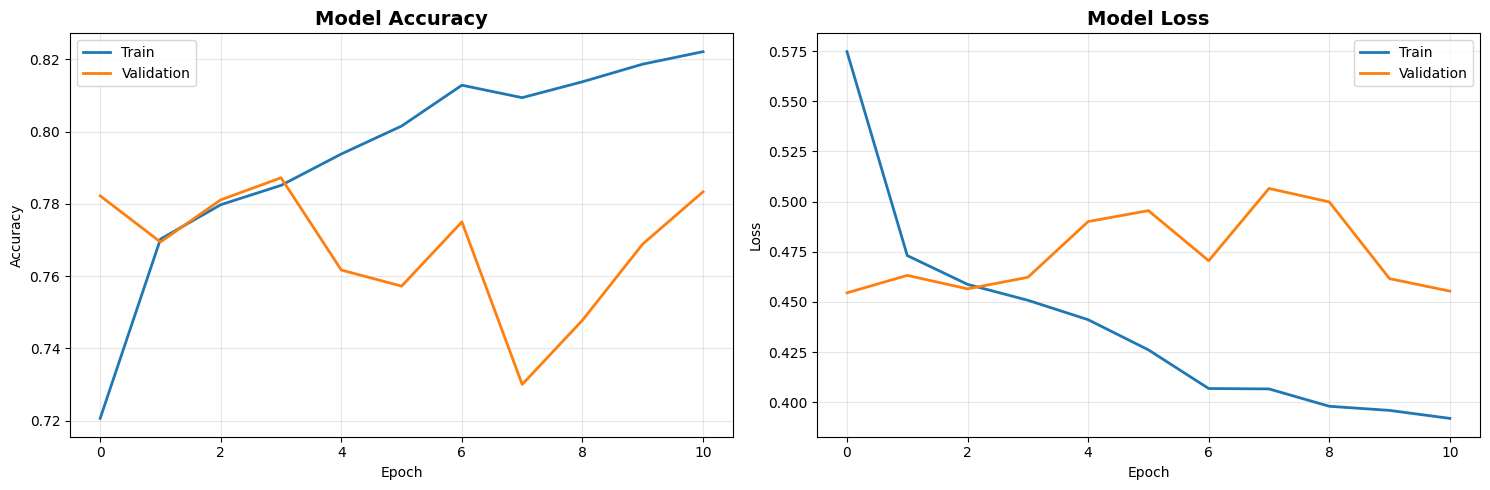

✓ Saved: training_history.png



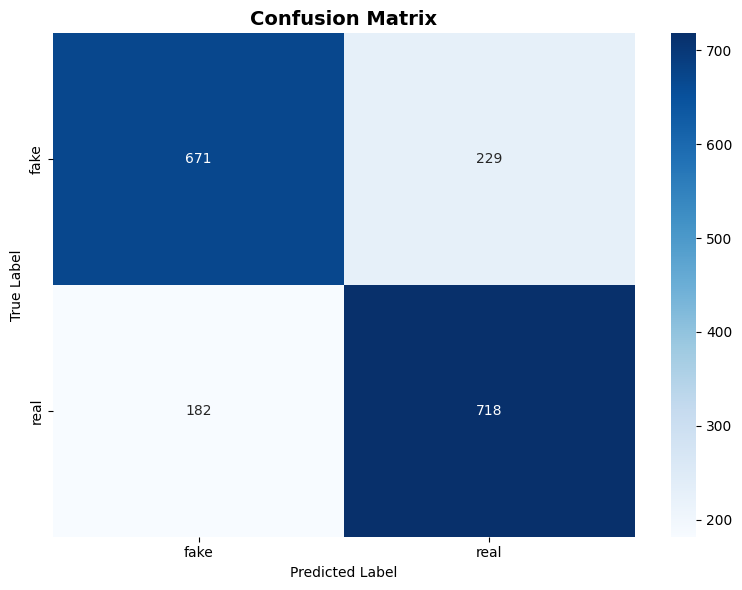

✓ Saved: confusion_matrix.png



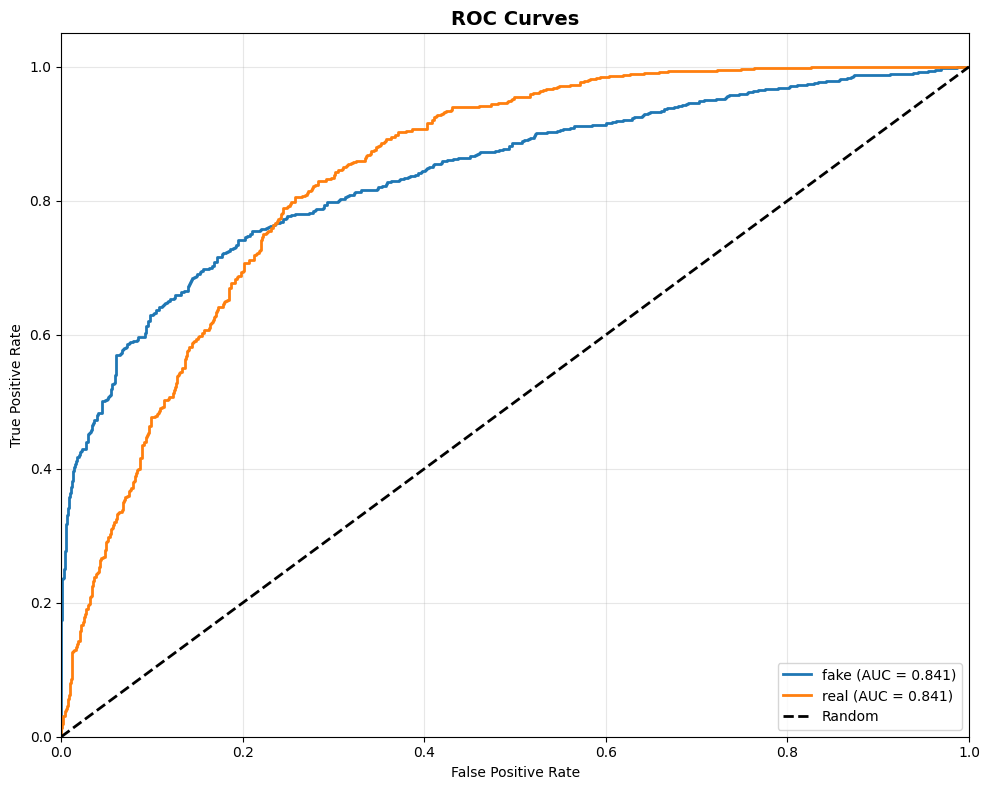

✓ Saved: roc_curve.png



In [33]:
# Evaluate
eval_results = detector.evaluate()

# Plot results
detector.plot_training_history()
detector.plot_confusion_matrix(
    eval_results['y_true'],
    eval_results['y_pred'],
    eval_results['class_names']
)
detector.plot_roc_curve(
    eval_results['y_true'],
    eval_results['y_pred_proba'],
    eval_results['class_names']
)

[FUZZY] Initializing Fuzzy Trust System...
✓ Fuzzy system initialized with 6 rules



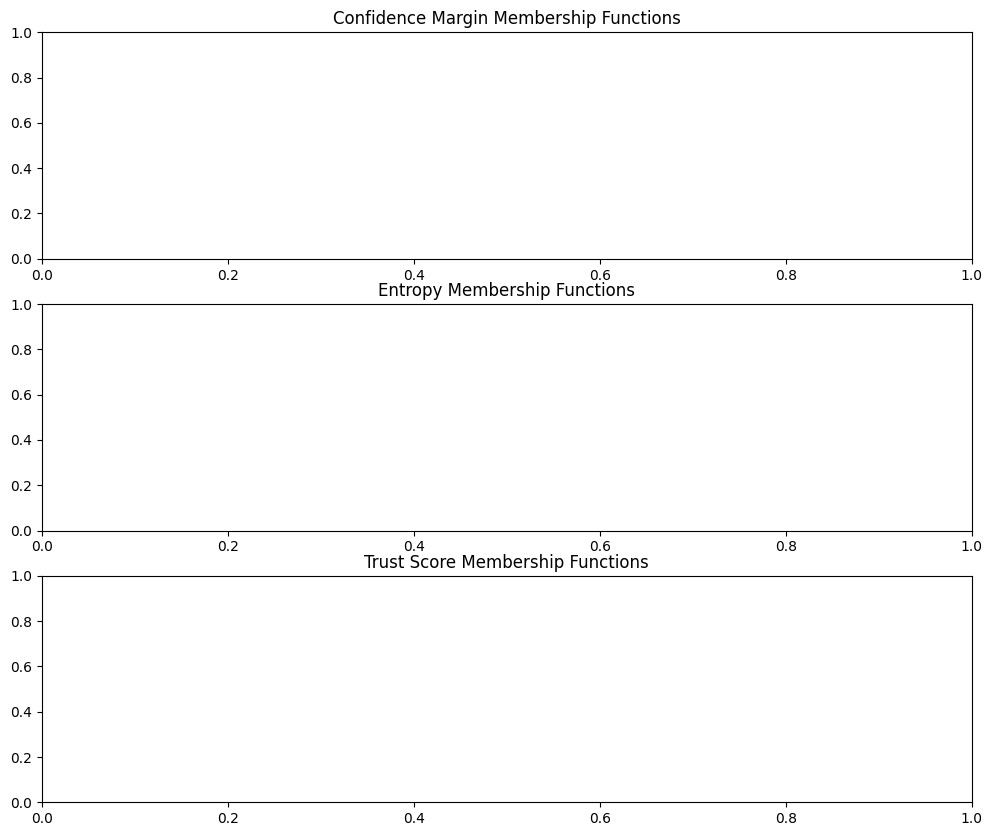

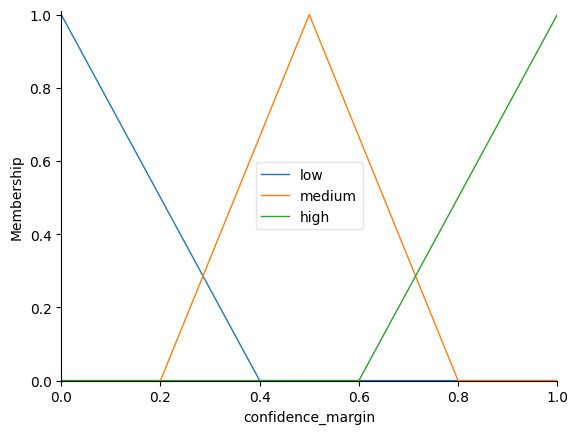

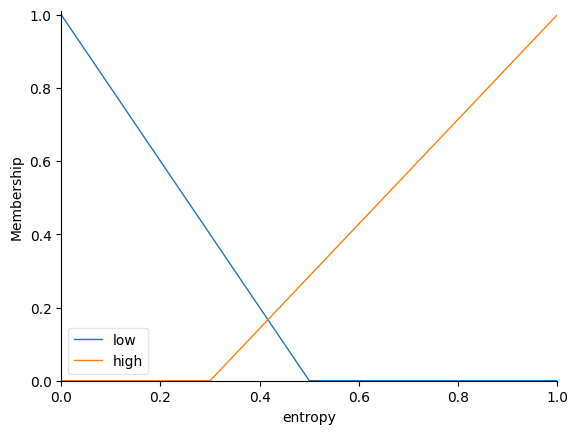

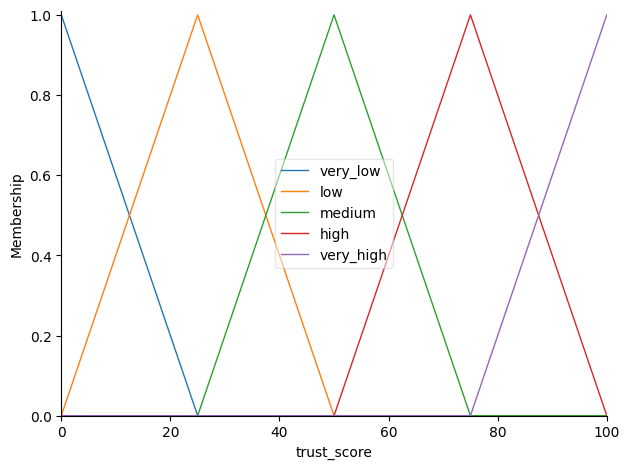

✓ Saved: fuzzy_membership.png


Testing Fuzzy System:

High confidence, Low uncertainty:
  Trust Score: 91.39/100
  ✓ AUTHENTIC

Medium confidence, High uncertainty:
  Trust Score: 25.00/100
  ✗ LIKELY DEEPFAKE

Low confidence, High uncertainty:
  Trust Score: 9.72/100
  ✗ LIKELY DEEPFAKE


In [35]:
# Initialize fuzzy system
fuzzy_system = FuzzyTrustSystem()
fuzzy_system.visualize_membership_functions()

# Test fuzzy system
test_cases = [
    (0.95, 0.1, "High confidence, Low uncertainty"),
    (0.5, 0.8, "Medium confidence, High uncertainty"),
    (0.2, 0.9, "Low confidence, High uncertainty"),
]

print("\nTesting Fuzzy System:")
print("="*70)
for conf, ent, desc in test_cases:
    score = fuzzy_system.calculate_trust_score(conf, ent)
    classification = fuzzy_system.classify_result(score)
    print(f"\n{desc}:")
    print(f"  Trust Score: {score:.2f}/100")
    print(f"  {classification}")

In [47]:
# Test with a single image
def detect_image(image_path):
    """Detect if image is real or fake"""
    # Load and preprocess
    img = load_img(image_path, target_size=(config.IMG_SIZE, config.IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = detector.model.predict(img_array, verbose=0)
    
    # Extract features
    features = ConfidenceExtractor.extract_features(predictions)
    
    # Calculate trust score
    trust_score = fuzzy_system.calculate_trust_score(
        features['confidence_margin'],
        features['entropy']
    )
    
    classification = new_classify_result(
    trust_score,
    features['p_real'],
    features['p_fake']
    )

    
    # Display results
    print("="*70)
    print("DETECTION RESULTS")
    print("="*70)
    print(f"P(Real):           {features['p_real']:.4f} ({features['p_real']*100:.2f}%)")
    print(f"P(Fake):           {features['p_fake']:.4f} ({features['p_fake']*100:.2f}%)")
    print(f"Confidence Margin: {features['confidence_margin']:.4f}")
    print(f"Entropy:           {features['entropy']:.4f}")
    print(f"Trust Score:       {trust_score:.2f}/100")
    print(f"Classification:    {classification}")
    print("="*70)
    
    # Show image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{classification}\nTrust Score: {trust_score:.2f}/100")
    plt.axis('off')
    plt.show()
    
    return {'features': features, 'trust_score': trust_score, 'classification': classification}

# Usage:
# result = detect_image('path/to/your/image.jpg')
print("✓ detect_image() function ready")
print("\nUsage: result = detect_image('path/to/your/image.jpg')")

✓ detect_image() function ready

Usage: result = detect_image('path/to/your/image.jpg')


In [15]:
print(detector.history.history['val_accuracy'][-1])

0.7622222304344177


In [45]:
def new_classify_result(trust_score, p_real, p_fake):

    # Decide class from CNN
    if p_real > p_fake:
        base_prediction = "✓ REAL"
    else:
        base_prediction = "✗ FAKE"

    # Determine confidence level
    if trust_score >= 70:
        confidence = "HIGH CONFIDENCE"
    elif trust_score >= 40:
        confidence = "MODERATE CONFIDENCE"
    else:
        confidence = "LOW CONFIDENCE"

    return f"{base_prediction} ({confidence})"


DETECTION RESULTS
P(Real):           0.5072 (50.72%)
P(Fake):           0.4928 (49.28%)
Confidence Margin: 0.0144
Entropy:           0.9999
Trust Score:       8.34/100
Classification:    ✓ REAL (LOW CONFIDENCE)


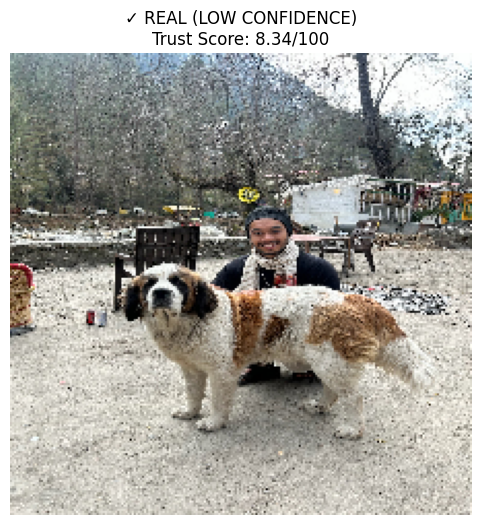

In [59]:
result = detect_image("IMG_0244.jpeg")

DETECTION RESULTS
P(Real):           0.5687 (56.87%)
P(Fake):           0.4313 (43.13%)
Confidence Margin: 0.1374
Entropy:           0.9863
Trust Score:       9.06/100
Classification:    ✓ REAL (LOW CONFIDENCE)


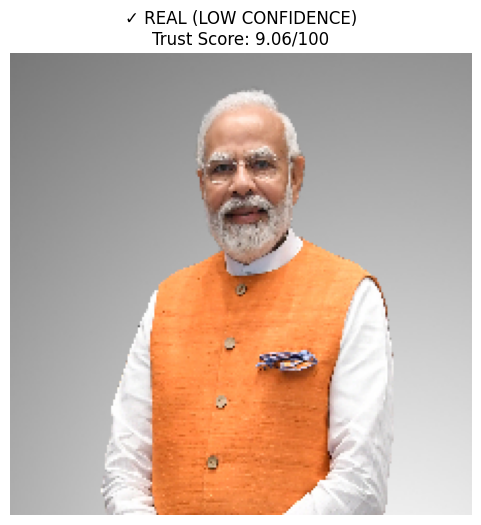

In [65]:
result = detect_image("real.jpeg")

DETECTION RESULTS
P(Real):           0.7072 (70.72%)
P(Fake):           0.2928 (29.28%)
Confidence Margin: 0.4143
Entropy:           0.8724
Trust Score:       25.00/100
Classification:    ✓ REAL (LOW CONFIDENCE)


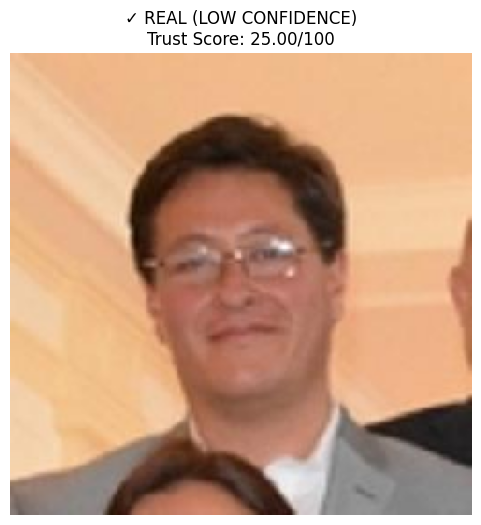

In [49]:
result = detect_image("real_10043.jpg")

DETECTION RESULTS
P(Real):           0.0419 (4.19%)
P(Fake):           0.9581 (95.81%)
Confidence Margin: 0.9163
Entropy:           0.2508
Trust Score:       90.27/100
Classification:    ✗ FAKE (HIGH CONFIDENCE)


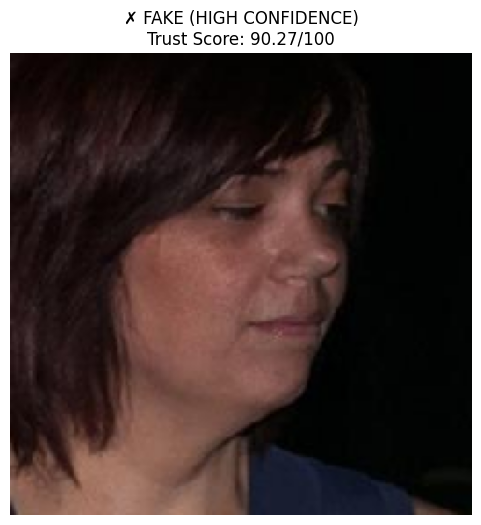

DETECTION RESULTS
P(Real):           0.7564 (75.64%)
P(Fake):           0.2436 (24.36%)
Confidence Margin: 0.5127
Entropy:           0.8010
Trust Score:       25.00/100
Classification:    ✓ REAL (LOW CONFIDENCE)


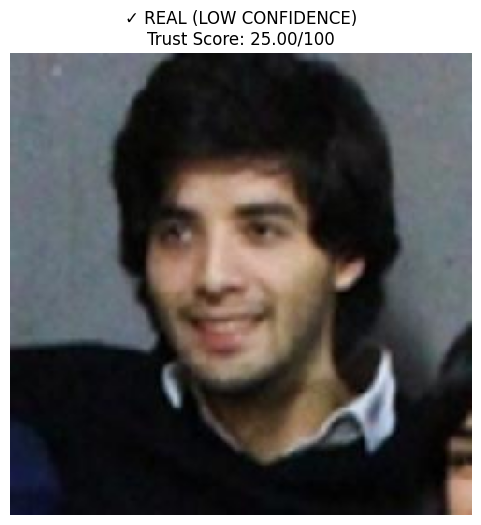

In [61]:
result = detect_image("fake_10009.jpg")
result = detect_image("real_52.jpg")

DETECTION RESULTS
P(Real):           0.2315 (23.15%)
P(Fake):           0.7685 (76.85%)
Confidence Margin: 0.5370
Entropy:           0.7807
Trust Score:       25.00/100
Classification:    ✗ FAKE (LOW CONFIDENCE)


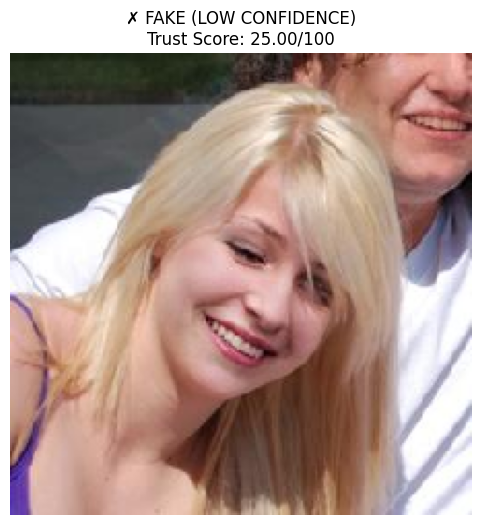

In [57]:
result = detect_image("fake_4152.jpg")

DETECTION RESULTS
P(Real):           0.7334 (73.34%)
P(Fake):           0.2666 (26.66%)
Confidence Margin: 0.4669
Entropy:           0.8365
Trust Score:       25.00/100
Classification:    ✓ REAL (LOW CONFIDENCE)


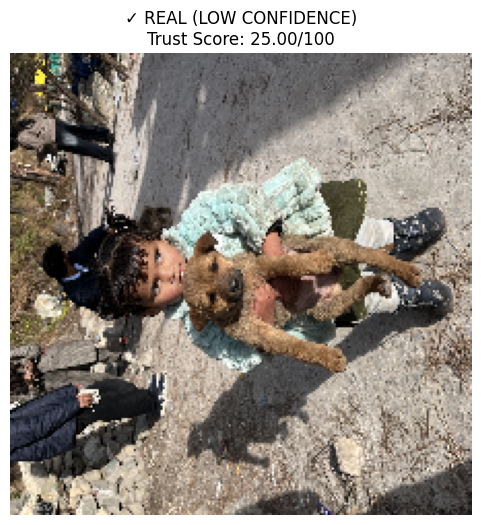

In [69]:
result = detect_image("IMG_6998.JPG")

In [67]:
# Save the trained model
detector.model.save(config.MODELS_DIR / 'deepfake_model_final.h5')
print(f"✓ Model saved to: {config.MODELS_DIR / 'deepfake_model_final.h5'}")

print("\n" + "="*70)
print("✓ SYSTEM COMPLETE!")
print("="*70)
print(f"\nResults saved in: {config.RESULTS_DIR}")
print(f"Model saved in: {config.MODELS_DIR}")

✓ Model saved to: models\deepfake_model_final.h5

✓ SYSTEM COMPLETE!

Results saved in: results
Model saved in: models
